<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Daily_Session_work/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Most Imp Interview question
# what is logistic regression? can u explian
# what is logit/sigmoid function?

In [6]:
import pandas as pd

path = 'https://raw.githubusercontent.com/hakimyameen/Datasets/refs/heads/main/heart.csv'

h = pd.read_csv(path)
h[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
h['target'].value_counts()

,count
target,
1,50490
0,42228


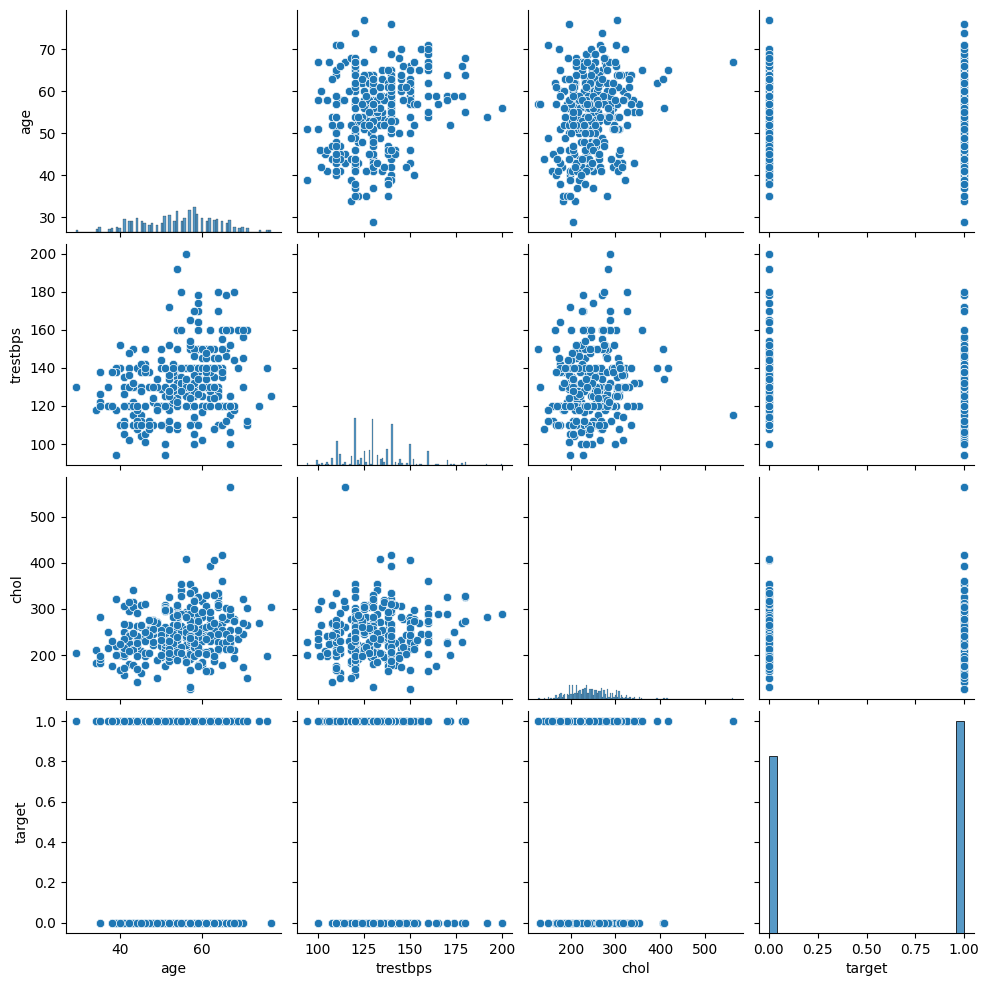

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data=h[['age','trestbps','chol','target']])

In [9]:
# data prepare
X = h[['age','trestbps','chol']]

y = h['target']

# X=h[["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]]
# y=h["target"] --------Train data score: 0.8585218540189284
# Test data score: 0.8563416738567731

# X=h[["cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal"]]
# y=h["target"]  Train data score: 0.841763960417397
# Test data score: 0.840864969801553

# X=h[["age","sex","cp","trestbps","chol","fbs"]]
# y=h["target"]  Train data score: 0.7753795130369132
# Test data score: 0.776369715271786

# X=h[["restecg","thalach","exang","oldpeak","slope","ca","thal"]]
# y=h["target"] Train data score: 0.8022352846010732
# Test data score: 0.8009598792062123

# X=h[["trestbps","chol","fbs","restecg","thalach","exang"]]
# y=h["target"]  Train data score: 0.7333567018092593
# # Test data score: 0.7299396031061259







In [10]:
# split the dataset
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [11]:
# Train the model
from sklearn.linear_model import LogisticRegression as logisticRegression
model=logisticRegression()
model

LogisticRegression()

In [12]:
model.fit(X_train,y_train)

LogisticRegression()

In [13]:
# Testing
y_pred = model.predict(X_test)
y_pred


array([1, 0, 0, ..., 0, 1, 1])

In [14]:
# check data score
print("Train data score:",model.score(X_train,y_train))
print("Test data score:",model.score(X_test,y_test))

Train data score: 0.6221317442769704
Test data score: 0.6137834339948232


In [15]:
# model.predict_proba([[90,130,204]])

In [16]:
# highest features for better score

## **Performance metrics  for classification problem**

In [17]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score


In [18]:
# actual output and predicted output
cm=confusion_matrix(y_test,y_pred)
cm

array([[4199, 4341],
       [2821, 7183]])

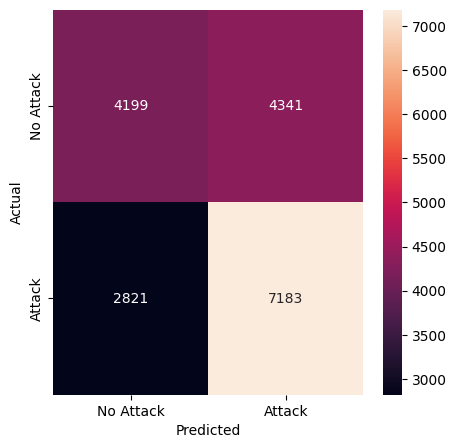

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['No Attack','Attack'],yticklabels=['No Attack','Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
# accuracy=TP+TN/TOTAL
len(y_test)

18544

In [21]:
(cm[0][0]+cm[1][1])/len(y_test)

np.float64(0.6137834339948232)

In [22]:
accuracy_score(y_test,y_pred)*100

61.37834339948232

In [23]:
precision_score(y_test,y_pred)*100

62.33078792086081

In [24]:
recall_score(y_test,y_pred)*100

71.80127948820471

In [25]:
f1_score(y_test,y_pred)*100


66.73169825343739

In [26]:
# everything in one place
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.49      0.54      8540
           1       0.62      0.72      0.67     10004

    accuracy                           0.61     18544
   macro avg       0.61      0.60      0.60     18544
weighted avg       0.61      0.61      0.61     18544



In [27]:
# Assignment
# check confusion metrics for multiclass classification
# meaning--if w have more than 2 categories in prediction the how to read confusion matrics
# how to understand TP,TN,FP,FN


In [28]:
# INTERVIEW IMP:---->
# WHAT IS CONFUSION MATRIX
# EXPLIAN TP,TN,FP,FN AND EXPLIAN TYPE 1,2 ERROR
# WHAT IS PRECISION AND RECALL TELL ME FORMULA FOR THAT
# WHAT IS USE OF F1 SCORE
# WHY WE CANT RELY ON ACCCURACY?

In [29]:
# LETUS USE Decision tree on same data
from sklearn.tree import DecisionTreeClassifier


In [30]:
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [31]:
dt_pred=dt.predict(X_test)
dt_pred

array([1, 1, 0, ..., 0, 1, 0])

In [32]:
dt_pred[:2]

array([1, 1])

In [33]:
print("Training score",dt.score(X_train,y_train)*100)
print("Testing score",dt.score(X_test,y_test)*100)

Training score 100.0
Testing score 100.0


In [34]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8540
           1       1.00      1.00      1.00     10004

    accuracy                           1.00     18544
   macro avg       1.00      1.00      1.00     18544
weighted avg       1.00      1.00      1.00     18544



In [35]:
# # ASSIGNMENT test on other algorithms
# # Assignment: Test on other algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier



### K-Nearest Neighbors Classifier

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Training score:", knn.score(X_train, y_train) * 100)
print("KNN Testing score:", knn.score(X_test, y_test) * 100)
print(classification_report(y_test, knn_pred))

KNN Training score: 100.0
KNN Testing score: 100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8540
           1       1.00      1.00      1.00     10004

    accuracy                           1.00     18544
   macro avg       1.00      1.00      1.00     18544
weighted avg       1.00      1.00      1.00     18544



### Support Vector Classifier (SVC)

In [ ]:
from sklearn.svm import SVC

# Note: SVC can be computationally intensive and may take a long time to run on large datasets.
# For demonstration, we'll use default parameters.

svc = SVC()
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
print("SVC Training score:", svc.score(X_train, y_train) * 100)
print("SVC Testing score:", svc.score(X_test, y_test) * 100)
print(classification_report(y_test, svc_pred))

### Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)
print("GaussianNB Training score:", gnb.score(X_train, y_train) * 100)
print("GaussianNB Testing score:", gnb.score(X_test, y_test) * 100)
print(classification_report(y_test, gnb_pred))

### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42) # Using a random_state for reproducibility
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RandomForest Training score:", rf.score(X_train, y_train) * 100)
print("RandomForest Testing score:", rf.score(X_test, y_test) * 100)
print(classification_report(y_test, rf_pred))